<div class="alert alert-block alert-info">

Hello Juan! How are you? 😊

My name is Santiago. It's a pleasure to meet you and I will be your reviewer for this project.

Here is the review process we will follow:

When I find an error for the first time, I will point it out and let you detect and fix it on your own. I will also make observations to improve your code and comments about your conclusions.

Please **do not move, modify, or delete** my comments.

You will find my comments in colored boxes:

</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment.</b> ✅ Success. Everything was done correctly.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment.</b> ⚠️ Observation. Some minor recommendations or improvements.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment.</b> ❌ Needs correction. The work cannot be accepted with red comments.
</div>

<div class="alert alert-block alert-danger">

<b>General Review — Iteration 1</b> <a class="tocSkip"></a>

Before going into detail, I want to share my general impressions.

This project is one of the most **creative, complete, and well-documented** in the entire sprint series. The `scored` column for auditing missing reviews, the three-era classification (Retro/Classic/Modern), the platform lifecycle analysis with frequency of appearance/disappearance, the Declining/Mature/Emerging classification with a dynamic legend, the `get_top_records()` reusable function, the stacked market share chart with value labels, and the Levene test before the t-test are all initiatives that go well beyond what the rubric requires. The final conclusion is of executive report quality. ¡Excellent work!

**Main strengths:**
- Imports grouped at the start. ✅
- `/datasets/games.csv` correct path. ✅
- `scored` column to audit missing reviews — unique in the sprint. ✅
- Correct detection and fix of the DS-1985 outlier. ✅
- `total_sales` with all 4 regions. ✅
- Levene test before the t-test (H2). ✅
- Hypothesis H₀/H₁ formally stated in markdown before the code. ✅
- Complete executive conclusion with regional differentiation. ✅

**Two points that need correction:**

1. **Cell 13 — Missing values filled with `-1`** in `year_of_release`, `critic_score`, and `user_score`. Although you consistently filter with `!= -1`, the value `-1` is not a real score and can bias any calculation where the filter is forgotten.

2. **Cell 69 — Correlation performed on Wii**, despite Cell 68 stating "Xbox 360 was chosen." The comment and the code are inconsistent.

With those two adjustments the project is ready for approval. ¡Very close! 💪

</div>

<div class="alert alert-block alert-success">

<b>General Review — Iteration 2 ✅ PROJECT APPROVED</b> <a class="tocSkip"></a>

Hello Juan! I reviewed this second iteration carefully and the verdict is definitive: **all three points were corrected perfectly and the project is approved**. 🎉

**The three corrections — all impeccable:**

- ✅ **Missing values no longer filled with `-1`.** Cell 15 only fills `rating` with `'NO_RATING'`. Cell 19 correctly replaces `'tbd'` with `np.nan` followed by `astype('float')`. The analytical justification in Cell 18 (*"31% tbd — imputing with mean/median would distort the distribution"*) is methodologically correct and well-expressed. ✅

- ✅ **Correlation now performed on PS4.** Cell 77 filters `platform == 'PS4'` with `dropna(subset=['critic_score_10', 'user_score'])` before the scatterplots and `corr()`. The analysis is now relevant for the 2017 campaign planning objective. ✅

- ✅ **`equal_var` dynamic based on Levene result.** Cells 131-132 (H1) and 139-140 (H2) now compute `equal_var = levene_result.pvalue >= alpha` and pass that variable to `ttest_ind`. This is exactly the most rigorous implementation — the test automatically adapts to the data. ✅

This project is one of the most creative, complete, and technically sophisticated in the entire sprint series. The `scored` flag, the three-era classification, the Declining/Mature/Emerging platform taxonomy, the `get_top_records()` function, the stacked market share chart with value labels, and the dynamic Levene + t-test all reflect a level of analytical thinking well beyond what the rubric requires. ¡Congratulations, Juan! 🏆

</div>

# ICE Video Games Sales Analysis

## Project Description.

In this project, I will analyze historical video game sales data from the online store **Ice**, which sells video games worldwide. The dataset contains information about game sales, platforms, genres, user and critic reviews, and ESRB ratings.

The objective of this analysis is to identify the factors that contribute to a **game's success.** By finding patterns in historical data, it is possible to identify promising projects and support **marketing decisions** for future advertising campaigns.

The dataset includes information up to **2016.** For this project, we will assume that it is December 2016 and that the goal is to provide insights that can help plan **marketing strategies for 2017.**

## Project Workflow

The project will be developed in the following stages:

1. Data overview and initial **exploration**
2. Data **preparation** and preprocessing
3. Exploratory data **analysis** (EDA)
4. **User profile** analysis by region
5. **Hypothesis** testing
6. Final **conclusions** and business recommendations

## Main Objective

The main goal of this project is to determine which characteristics are associated with **successful video games.** The analysis will focus on factors such as:

* Sales performance across different regions
* Gaming platforms
* Game genres
* User reviews
* Critic reviews
* ESRB ratings

The results of this analysis may help identify trends and support decision-making for future **marketing campaigns.**

# 1. Data Overview

First, I will **load the dataset** and examine its structure. This includes reviewing the available columns, identifying missing values, checking data types, and obtaining a general understanding of the information provided.

This initial **inspection** will help detect potential data quality issues that need to be addressed before performing the analysis.

In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import math
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

In [2]:
# Upload data in a DataFrame
data = pd.read_csv('/datasets/games.csv')

# Display the first rows
data.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
# Display info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


**Findings:**
1. The **columns** names are witten with **capital letters.**
2. The **datatype** of the column 'Year' is float.
3. **Null values** in some columns

# 2. Data Preparation

Before starting the analysis, the dataset must be **cleaned and prepared.** The data preparation process includes:

- Converting column names to lowercase
- Checking and correcting data types
- Handling missing values
- Investigating unusual values
- Drop duplicates
- Creating a new variable for total global sales

These steps ensure that the dataset is consistent and suitable for analysis.

In [4]:
# Convert column names to lowercase and strip whitespace
data.columns = data.columns.str.lower().str.strip()

data.head(1)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E


## 2.1. Null Values

In [5]:
# Change the columns of 'name' to capital letters
data['name'] = data['name'].str.upper()

# Fill NaN values in rating column
data['rating'] = data['rating'].fillna('NO_RATING')

data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,WII SPORTS,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,SUPER MARIO BROS.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NO_RATING
2,MARIO KART WII,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,WII SPORTS RESORT,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,POKEMON RED/POKEMON BLUE,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NO_RATING


<div class="alert alert-block alert-danger">
<b>Reviewer's comment — Iteration 1</b> <a class="tocSkip"></a>

❌ **Cell 13 — Missing values filled with `-1` — introduces fictitious values**


Using `-1` as a substitute for missing values introduces a fictitious value that, while not a real score, can contaminate calculations if the `!= -1` filter is ever forgotten. This pattern also makes the code harder to read: a reader needs to know that `-1` means "missing", which is not intuitive.

**The correct approach is to preserve `NaN` and use `dropna()` when needed**

Then in correlations and hypotheses, use `.dropna()` explicitly. This way it's clear which records are being analyzed and why. Once corrected, also update the `mean_score` calculation in Cell 28, since it currently averages values that include `-1`.

</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment — Iteration 2</b> <a class="tocSkip"></a>

✅ **Null value handling — corrected perfectly.** No more `fillna(-1)`. Cell 15 only fills `rating` with `'NO_RATING'`. Cell 19 uses `.replace('tbd', np.nan)` + `.astype('float')` — the correct order. The analytical justification in Cell 18 is methodologically precise and well-expressed. ✅

</div>

In [6]:
# Verify the proportion of 'tbd' values in the 'user_score' column and determine whether they should be replaced with the mean, median, or NaN.
tbd_count = data[data['user_score'] == 'tbd']['user_score'].count()
total_count = data[data['user_score'] != 'tbd']['user_score'].dropna().count()

print(f'To be dertiminated: {(tbd_count/total_count*100):.2f}%')

To be dertiminated: 31.94%


Since **'tbd'** (to be determined) accounts for **31%** of the user scores, these values were left as **NaN**. Imputing them with the mean or median could distort the underlying distribution and introduce bias into the analysis.

In [7]:
# Replace 'tbd' values with NaN
data['user_score'].replace('tbd', np.nan, inplace=True)

# Convert data type to float
data['user_score'] = data['user_score'].astype('float')

data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,WII SPORTS,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,SUPER MARIO BROS.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NO_RATING
2,MARIO KART WII,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,WII SPORTS RESORT,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,POKEMON RED/POKEMON BLUE,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NO_RATING


<div class="alert alert-block alert-success">
<b>Reviewer's comment — Iteration 2</b> <a class="tocSkip"></a>

✅ **Null value handling — corrected perfectly.** No more `fillna(-1)`. Cell 15 only fills `rating` with `'NO_RATING'`. Cell 19 uses `.replace('tbd', np.nan)` + `.astype('float')` — the correct order. The analytical justification in Cell 18 is methodologically precise and well-expressed. ✅

</div>

In [8]:
# Validate the changes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


In [9]:
# View the games that no have name or genre
data[data['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NO_RATING
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NO_RATING


In [10]:
# Drop games that no have name and genre
data.dropna(subset=['name','genre'], inplace=True)

data.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16713 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


## 2.2. Duplicates

In [11]:
# View duplicated rows
print(data.duplicated().sum(), 'duplicated rows')

0 duplicated rows


In [12]:
# View duplicated games
print(data['name'].duplicated().sum(), 'duplicated games')

5154 duplicated games


In [13]:
# Array with duplicated games
data[data['name'].duplicated(keep=False)].sort_values(['name','platform']).head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
3358,FROZEN: OLAF'S QUEST,3DS,2013.0,Platform,0.27,0.27,0.00,0.05,NaN,NaN,NO_RATING
3862,FROZEN: OLAF'S QUEST,DS,2013.0,Platform,0.21,0.26,0.00,0.04,NaN,NaN,NO_RATING
9507,007: QUANTUM OF SOLACE,DS,2008.0,Action,0.11,0.01,0.00,0.01,65.0,NaN,T
14658,007: QUANTUM OF SOLACE,PC,2008.0,Action,0.01,0.01,0.00,0.00,70.0,6.3,T
4475,007: QUANTUM OF SOLACE,PS2,2008.0,Action,0.17,0.00,0.00,0.26,NaN,NaN,NO_RATING
1785,007: QUANTUM OF SOLACE,PS3,2008.0,Action,0.43,0.51,0.02,0.19,65.0,6.6,T
3120,007: QUANTUM OF SOLACE,Wii,2008.0,Action,0.29,0.28,0.01,0.07,54.0,7.5,T
1285,007: QUANTUM OF SOLACE,X360,2008.0,Action,0.82,0.51,0.01,0.14,65.0,7.1,T
1204,007: THE WORLD IS NOT ENOUGH,N64,2000.0,Action,1.13,0.38,0.02,0.03,NaN,NaN,NO_RATING
2243,007: THE WORLD IS NOT ENOUGH,PS,2000.0,Action,0.51,0.35,0.00,0.06,61.0,6.7,T


In [14]:
# Validate if there are duplicated games: name and platform
print(data[['name','platform']].duplicated().sum(), 'duplicated games')

4 duplicated games


In [15]:
# View the duplicated games: name and platform
data[data.duplicated(['name','platform'], keep=False)].sort_values(['name','platform'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,MADDEN NFL 13,PS3,2012.0,Sports,2.11,0.22,0.00,0.23,83.0,5.5,E
16230,MADDEN NFL 13,PS3,2012.0,Sports,0.00,0.01,0.00,0.00,83.0,5.5,E
5972,NEED FOR SPEED: MOST WANTED,PC,2005.0,Racing,0.02,0.23,0.00,0.04,82.0,8.5,T
11715,NEED FOR SPEED: MOST WANTED,PC,2012.0,Racing,0.00,0.06,0.00,0.02,82.0,8.5,T
1190,NEED FOR SPEED: MOST WANTED,X360,2012.0,Racing,0.62,0.78,0.01,0.15,83.0,8.5,T
1591,NEED FOR SPEED: MOST WANTED,X360,2005.0,Racing,1.00,0.13,0.02,0.10,83.0,8.5,T
1745,SONIC THE HEDGEHOG,PS3,2006.0,Platform,0.41,0.06,0.04,0.66,43.0,4.1,E10+
4127,SONIC THE HEDGEHOG,PS3,NaN,Platform,0.00,0.48,0.00,0.00,43.0,4.1,E10+


- **Need for Speed: Most Wanted** was retained because two different versions of the game exist: one released in `2005` and another in `2012`.
- All other duplicate games will be **removed.**

In [16]:
# Drop duplicated games (exception Need for speed)
data.drop([16230,4127], inplace=True)

In [17]:
# Reset Index
data.reset_index(inplace=True, drop=True)

## 2.3. Data Enrichment

In [18]:
# New column with total sales
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']

In [19]:
# New column with critic score divided by 10
data['critic_score_10'] = data['critic_score'] / 10

# New column with mean scores: critics and users
data['mean_score'] = (data['critic_score_10'] + data['user_score']) / 2

In [20]:
data.sort_values('total_sales', ascending=False).head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,critic_score_10,mean_score
0,WII SPORTS,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,7.6,7.80
1,SUPER MARIO BROS.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NO_RATING,40.24,NaN,NaN
2,MARIO KART WII,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,8.2,8.25
3,WII SPORTS RESORT,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,8.0,8.00
4,POKEMON RED/POKEMON BLUE,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NO_RATING,31.38,NaN,NaN


- **New columns** were created to place critic and user ratings on a **common scale**. A new composite score was also calculated by **averaging** the **two ratings.**

In [21]:
# Separate scored data
data['scored'] = data['critic_score'].isna()
data['scored'].replace(False,'With score', inplace=True)
data['scored'].replace(True,'Non score', inplace=True)
data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,critic_score_10,mean_score,scored
0,WII SPORTS,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,7.6,7.80,With score
1,SUPER MARIO BROS.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NO_RATING,40.24,NaN,NaN,Non score
2,MARIO KART WII,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,8.2,8.25,With score
3,WII SPORTS RESORT,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,8.0,8.00,With score
4,POKEMON RED/POKEMON BLUE,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NO_RATING,31.38,NaN,NaN,Non score


The following analysis focuses on identifying the reasons why most records lack rating information.

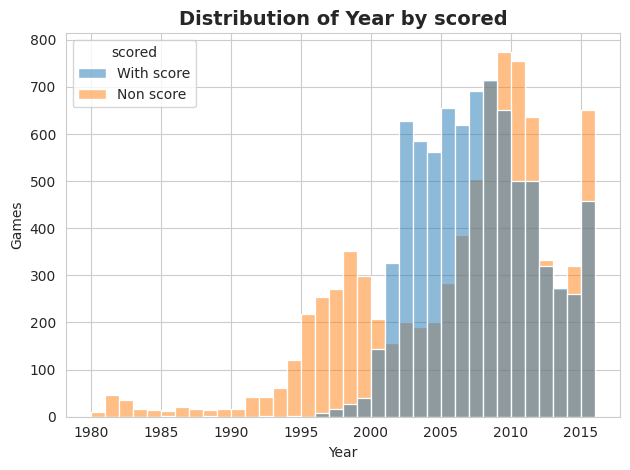

In [22]:
# Distribution of the years by scored games to find patterns
# Seaborn style
sns.set_style('whitegrid')

# Cration of year histogram by scored
sns.histplot(
    data=data.dropna(subset=['year_of_release']),
    x='year_of_release',
    hue='scored',
    bins=36
)

# Agregate Title and axes labes
plt.title('Distribution of Year by scored', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Games')

# Show grph
plt.tight_layout()
plt.show()



In [23]:
# View the oldest scored games
data[data['scored'] == 'With score'].dropna(subset=['year_of_release']).sort_values('year_of_release').head(6)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,critic_score_10,mean_score,scored
14467,ALTER EGO,PC,1985.0,Simulation,0.00,0.03,0.00,0.01,59.0,5.8,T,0.04,5.9,5.85,With score
14618,SIMCITY,PC,1988.0,Simulation,0.00,0.02,0.00,0.01,64.0,2.2,E10+,0.03,6.4,4.30,With score
14607,DOOM,PC,1992.0,Shooter,0.02,0.00,0.00,0.00,85.0,8.2,M,0.02,8.5,8.35,With score
1566,BATTLE ARENA TOSHINDEN,PS,1994.0,Fighting,0.39,0.26,0.53,0.08,69.0,6.3,T,1.26,6.9,6.60,With score
1159,DIABLO,PC,1996.0,Role-Playing,0.01,1.58,0.00,0.00,94.0,8.7,M,1.59,9.4,9.05,With score
9212,SUPER PUZZLE FIGHTER II TURBO,PS,1996.0,Puzzle,0.08,0.05,0.00,0.01,83.0,7.4,E,0.14,8.3,7.85,With score


In [24]:
# Group by scored and platform
platform_group = data.groupby(['scored','platform']).count().reset_index()[['scored','platform','name']].sort_values(['scored','name','platform'], ascending=False)
platform_group

,scored,platform,name
38,With score,PS2,1298
45,With score,X360,916
39,With score,PS3,818
46,With score,XB,725
33,With score,DS,717
36,With score,PC,715
43,With score,Wii,585
41,With score,PSP,462
35,With score,GC,448
34,With score,GBA,438


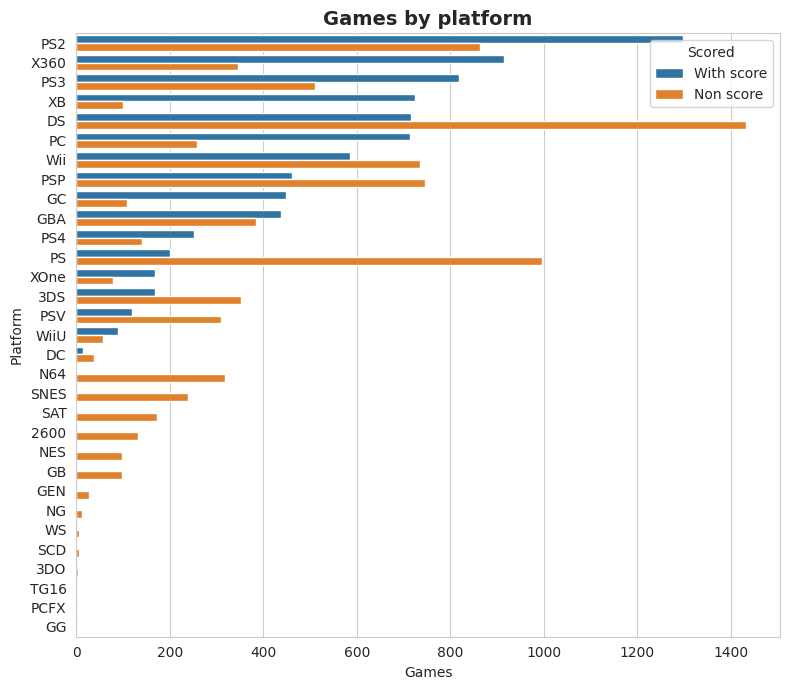

In [25]:
# Number of games by platforms
# Seaborn style
sns.set_style('whitegrid')

# Figure size
plt.figure(figsize=(8,7))

# Cration of year histogram by scored
sns.barplot(
    data=platform_group,
    x='name',
    y='platform',
    hue='scored'
)

# Agregate Title and axes labes
plt.title('Games by platform', fontsize=14, fontweight='bold')
plt.xlabel('Games')
plt.ylabel('Platform')

# Change the title of the legend
plt.legend(title='Scored')

# Show grph
plt.tight_layout()
plt.show()


In [26]:
# Group sales by scored games to validate if a region is dependant to non scored games
sales = data.groupby(['scored']).sum()[['na_sales','eu_sales','jp_sales','other_sales','total_sales']].reset_index().melt(
    id_vars='scored',
    value_vars=['na_sales', 'eu_sales', 'jp_sales', 'other_sales'],
    var_name='region',
    value_name='sales'
)
    
sales

,scored,region,sales
0,Non score,na_sales,1528.37
1,With score,na_sales,2872.20
2,Non score,eu_sales,729.11
3,With score,eu_sales,1694.54
4,Non score,jp_sales,849.58
5,With score,jp_sales,447.76
6,Non score,other_sales,201.84
7,With score,other_sales,589.40


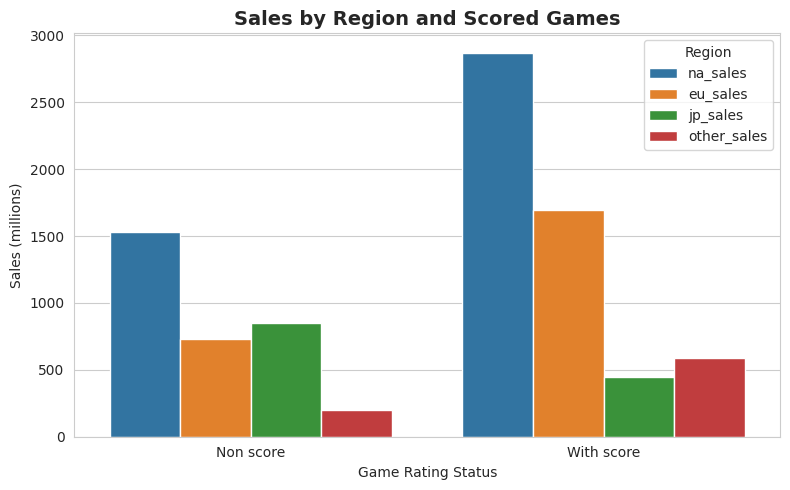

In [27]:
# Graph size
plt.figure(figsize=(8,5))

# Bar graph
sns.barplot(
    data=sales,
    x='scored',
    y='sales',
    hue='region'
)

# Set the title and axis labels
plt.title('Sales by Region and Scored Games', fontsize=14, fontweight='bold')
plt.xlabel('Game Rating Status')
plt.ylabel('Sales (millions)')
plt.legend(title='Region')

# Show graph
plt.tight_layout()
plt.show()

In [28]:
# View year error of game Saikyou Toudai Shogi DS
data[(data['platform'] == 'DS') & (data['year_of_release'] < 2000 )]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,critic_score_10,mean_score,scored
15954,STRONGEST TOKYO UNIVERSITY SHOGI DS,DS,1985.0,Action,0.0,0.0,0.02,0.0,NaN,NaN,NO_RATING,0.02,NaN,NaN,Non score


In [29]:
# Change to the correct year
data.loc[15954,'year_of_release'] = 2007
data[data['name'] == 'STRONGEST TOKYO UNIVERSITY SHOGI DS']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,critic_score_10,mean_score,scored
15954,STRONGEST TOKYO UNIVERSITY SHOGI DS,DS,2007.0,Action,0.0,0.0,0.02,0.0,NaN,NaN,NO_RATING,0.02,NaN,NaN,Non score



## 2.4. Data Preparation Summary

* **Column names** were converted to **lowercase.**
* The values in the **name** column were converted to **uppercase** to identify duplicate game titles.
* In the **user_score** column, **'tbd'** (to be determined) values were **replaced** with **NaN**, as they represented 31% of all user ratings and could not be reliably estimated.
* **Missing values** in **year_of_release**, **critic_score**, and **user_score** were **retained as NaN**. During subsequent analyses, the dropna() function will be applied when necessary to exclude observations with missing data.
* Records with **missing game names** were removed.
* **Two duplicate** records were identified and removed.
* *Need for Speed: Most Wanted* **was not removed** because the dataset contains two different versions of the game, released in 2005 and 2012.
* A new column containing **total sales** was added.
* A new column containing **mean scores** (critic and user) was added.
* Although game ratings have been available since **1996**, the presence of a rating does **not** show a clear **relationship** with the release **period, platform, or sales region.** Nevertheless, part of the missing rating data can be attributed to games released on **older consoles**, particularly those distributed in **Japan.**
* **Correct the year** of the game *Saikyou Toudai Shogi DS*: 1985 to 2007.

<div class="alert alert-block alert-success">
<b>Reviewer's comment — Iteration 1</b> <a class="tocSkip"></a>

✅ **Remaining data preparation — correct and well documented:**

- Column names to lowercase + strip. ✅
- Duplicate detection by `name` and by `name + platform`. ✅
- Correct reasoning for keeping *Need for Speed: Most Wanted* (two different versions). ✅
- `total_sales` with all 4 regions. ✅
- Detection and correction of the DS-1985 outlier (Cell 39-40). ✅
- `scored` column as audit flag — creative and methodologically valuable. ✅
- Preparation summary in Cell 41 — clear and complete. ✅

</div>

# 3. Data Analisys

In this part of the proyect, it will analizy:

* Game Release Year Distribution
* Platform Sales Comparison
* Platform Lifecycle Analysis
* Effect of Review Scores on Sales
* Cross-Platform Sales Comparison
* Highest-Grossing Game Genres


## 3.1. Game Release

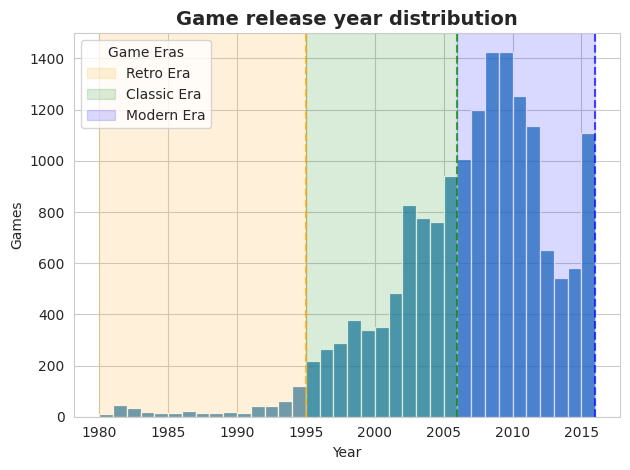

In [30]:
# Game release year distribution
# Seaborn style
sns.set_style('whitegrid')


# Cration of year histogram by scored
sns.histplot(
    data=data.dropna(subset=['year_of_release']),
    x='year_of_release',
    bins=36
)

# Add period ranges
plt.axvspan(1980, 1995, alpha=0.15, color='orange', label='Retro Era')
plt.axvspan(1995, 2006, alpha=0.15, color='green', label='Classic Era')
plt.axvspan(2006, 2016, alpha=0.15, color='blue', label='Modern Era')
plt.axvline(1995, color='orange', linestyle='--', alpha=0.7)
plt.axvline(2006, color='green', linestyle='--', alpha=0.7)
plt.axvline(2016, color='blue', linestyle='--', alpha=0.7)

# Agregate Title and axes labes
plt.title('Game release year distribution', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Games')

# Show legend
plt.legend(title='Game Eras')

# Show grph
plt.tight_layout()
plt.show()




In [31]:
# Percentage of Games by Era

retro_per = len(data[data['year_of_release'] < 1995]) / (len(data.dropna(subset=['year_of_release'])))
classic_per = len(data[data['year_of_release'] < 2006]) / (len(data.dropna(subset=['year_of_release'])))
modern_per = len(data[data['year_of_release'] >= 2006]) / (len(data.dropna(subset=['year_of_release'])))

print(f'Retro: {retro_per*100:.2f}%')
print(f'Classic: {classic_per*100:.2f}%')
print(f'Modern: {modern_per*100:.2f}%')

Retro: 2.95%
Classic: 37.16%
Modern: 62.84%


## 3.2. Platform Sales

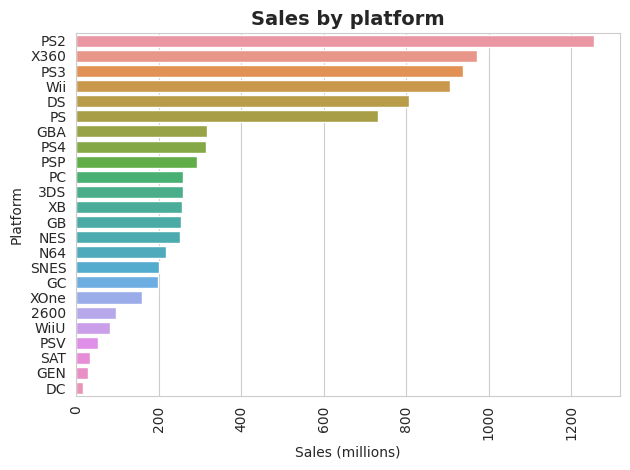

In [32]:
# Sales by platform
sales_by_platform = data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index(drop=False)

# Graph creation
sns.barplot(
    data=sales_by_platform.head(24),
    x='total_sales',
    y='platform',
    #x='platform',
    #y='total_sales',
)

# Set the title and axis labels
plt.title('Sales by platform', fontsize=14, fontweight='bold')
plt.ylabel('Platform')
plt.xlabel('Sales (millions)')

# Rotation of x labels
plt.xticks(rotation=90)

# Show graph
plt.tight_layout()
plt.show()


In [33]:
# PC info
sales_by_platform[sales_by_platform['platform'] == 'PC']

,platform,total_sales
9,PC,259.52


In [34]:
# Top 6 plataforms with more sales
top6_platforms = sales_by_platform['platform'].head(6).to_list()
top6_platforms

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']

In [35]:
# Filter the data of top 6 platforms
top6_data = data[data['platform'].isin(top6_platforms)].dropna(subset=['year_of_release'])
top6_data = top6_data.groupby(['platform','year_of_release'])['total_sales'].sum().reset_index()
top6_data

,platform,year_of_release,total_sales
0,DS,2004.0,17.27
1,DS,2005.0,130.14
2,DS,2006.0,119.81
3,DS,2007.0,146.96
4,DS,2008.0,145.31
...,...,...,...
61,X360,2012.0,99.74
62,X360,2013.0,88.58
63,X360,2014.0,34.74
64,X360,2015.0,11.96


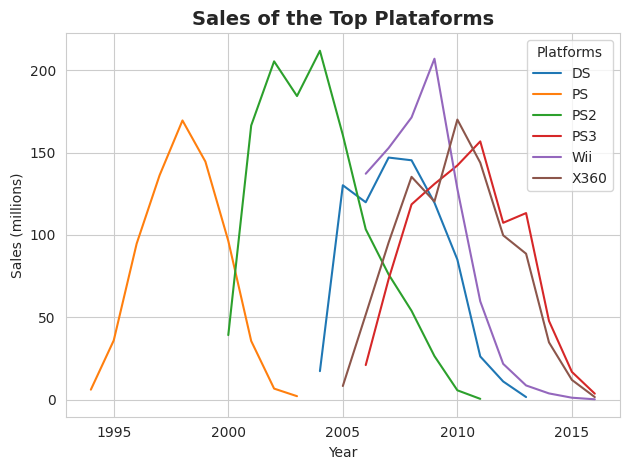

In [36]:
# Year distribution of Top 6 platforms with more sales
# Seaborn style
sns.set_style('whitegrid')

# Cration of year histogram
sns.lineplot(
    data=top6_data,
    x='year_of_release',
    y='total_sales',
    hue='platform',
)


# Agregate Title and axes labes
plt.title('Sales of the Top Plataforms', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Sales (millions)')


# Show legend
plt.legend(title='Platforms')

# Show grph
plt.tight_layout()
plt.show()


## 3.3. Platform Lifecycle

In [37]:
# Data group by platform with sales, year of start and end, years duration 
agg_dict={
    'year_of_release':['min','max'],
    'total_sales':'sum'
}

platforms_info = data.dropna(subset=['year_of_release']).groupby('platform') # filter the years -1 and group
platforms_info = platforms_info.agg(agg_dict) # agg function
platforms_info['life_years'] = platforms_info['year_of_release','max'] - platforms_info['year_of_release','min'] # new column of the duration of the platform
platforms_info['frequency_appers'] = platforms_info['year_of_release','min'].sort_values().diff() # New column with the difference of the platform start year 
platforms_info['frequency_desappers'] = platforms_info['year_of_release','max'].sort_values().diff() # New column with the difference of the platform end year

platforms_info.head()

year_of_release         total_sales life_years frequency_appers  \
                     min     max         sum                               
platform                                                                   
2600              1980.0  1989.0       86.48        9.0              NaN   
3DO               1994.0  1995.0        0.10        1.0              0.0   
3DS               2011.0  2016.0      257.81        5.0              0.0   
DC                1998.0  2008.0       15.95       10.0              2.0   
DS                2004.0  2013.0      802.78        9.0              3.0   

         frequency_desappers  
                              
platform                      
2600                     NaN  
3DO                      1.0  
3DS                      0.0  
DC                       0.0  
DS                       2.0

In [38]:
# Mean of the duration of the platforms
print('Mean of the duration of platforms:', platforms_info['life_years'].mean(), 'years')

# Median of the duration of the platforms
print('Median of the duration of platforms:', platforms_info['life_years'].median(), 'years')
print()

# Mean of the top 6 platforms with more sales
print('Mean of the duration of top 6 platforms:', platforms_info.sort_values(('total_sales','sum'), ascending=False).head(6)['life_years'].mean(), 'years')

# Median of the top 6 platforms with more sales
print('Median of the duration of top 6 platforms:', platforms_info.sort_values(('total_sales','sum'), ascending=False).head(6)['life_years'].median(), 'years')
print()

# Mean of the rest of platforms
print('Mean of the duration of the rest of the platforms:', platforms_info.sort_values(('total_sales','sum'), ascending=False).tail(len(platforms_info)-6)['life_years'].mean(), 'years')

# Median of the rest of platforms
print('Median of the duration of the rest of the platforms:', platforms_info.sort_values(('total_sales','sum'), ascending=False).tail(len(platforms_info)-6)['life_years'].median(), 'years')

Mean of the duration of platforms: 7.0 years
Median of the duration of platforms: 6.0 years

Mean of the duration of top 6 platforms: 10.0 years
Median of the duration of top 6 platforms: 10.0 years

Mean of the duration of the rest of the platforms: 6.28 years
Median of the duration of the rest of the platforms: 5.0 years


In [39]:
# Frequency of new platforms
print('Frequency of new platforms:', platforms_info['frequency_appers'].mean(), 'years')

# Frequency of die platforms
print('Frequency of die platforms:', platforms_info.sort_values(('year_of_release','max')).head(len(platforms_info)-9)['frequency_desappers'].mean().round(1), 'years') # Platforms that remain active beyond 2016 were excluded, as new games continue to be released for them.

Frequency of new platforms: 1.1 years
Frequency of die platforms: 1.2 years


* Platforms with the **highest sales** volumes generally have lifespans of approximately `10 years`.
* **Lower-performing** or less widely adopted platforms tend to have shorter lifespans, typically lasting no more than `6 years`.
* The video game industry exhibits a continuous renewal cycle, with roughly **one new console** being introduced **each year** while another reaches the **end** of its **lifecycle** and ceases to receive new game releases.

## 3.4. Significant Data

From this point onward, only data from **2005 and later** will be considered. Non-significant platforms have been excluded from the analysis.

In [40]:
# Data of recently years
year = 2005
recently_data = data[data['year_of_release'] >= year]
recently_data.sort_values('year_of_release').head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,critic_score_10,mean_score,scored
6765,CATZ,GBA,2005.0,Simulation,0.18,0.06,0.0,0.00,NaN,7.9,E,0.24,NaN,NaN,Non score
12533,SERIOUS SAM II,XB,2005.0,Shooter,0.05,0.01,0.0,0.00,72.0,6.7,M,0.06,7.2,6.95,With score
7253,NBA 06,PSP,2005.0,Sports,0.20,0.00,0.0,0.02,72.0,5.4,E,0.22,7.2,6.30,With score
7234,FROM RUSSIA WITH LOVE,GC,2005.0,Action,0.17,0.04,0.0,0.01,70.0,8.5,T,0.22,7.0,7.75,With score
12572,TOKYO XTREME RACER ADVANCE,GBA,2005.0,Racing,0.04,0.02,0.0,0.00,NaN,NaN,E,0.06,NaN,NaN,Non score


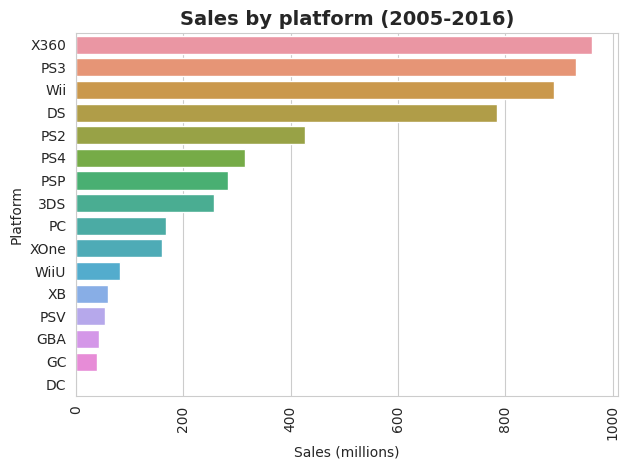

In [41]:
# Sales liders platforms
sales_by_platform = recently_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()


# Graph creation
sns.barplot(
    data=sales_by_platform,
    x='total_sales',
    y='platform',
    #x='platform',
    #y='total_sales',
)

# Set the title and axis labels
plt.title(f'Sales by platform ({year}-2016)', fontsize=14, fontweight='bold')
plt.ylabel('Platform')
plt.xlabel('Sales (millions)')

# Rotation of x labels
plt.xticks(rotation=90)

# Show graph
plt.tight_layout()
plt.show()


The five lowest-selling platforms will be removed from the dataset because they were in the declining stage of their lifecycle and had minimal impact on the market during the period analyzed.

In [42]:
# List of droped platforms
drop_plataforms = ['DC', 'GBA', 'XB', 'GC', 'PSV'] # Platforms that they aren´t relevant

# Drop the platforms that they aren´t relevant
recently_data = recently_data[~(recently_data['platform'].isin(drop_plataforms))]

# Group by platform and year
sales_by_platform =  recently_data.groupby(['platform','year_of_release'])['total_sales'].sum().reset_index()

# Dictionary of plataforms groups
group_dict = {
    'PS2':'Declining',
    'DS':'Declining',
    'PC':'Mature',
    'PSP':'Mature',
    'PS3':'Mature',
    'X360':'Mature',
    'Wii':'Mature',
    'PS4':'Emerging',
    'XOne':'Emerging',
    'WiiU':'Emerging',
    '3DS':'Emerging',
}

# Creating a new column with the group platform
sales_by_platform['group'] = sales_by_platform['platform'].map(group_dict)

sales_by_platform

,platform,year_of_release,total_sales,group
0,3DS,2011.0,63.20,Emerging
1,3DS,2012.0,51.36,Emerging
2,3DS,2013.0,56.57,Emerging
3,3DS,2014.0,43.76,Emerging
4,3DS,2015.0,27.78,Emerging
...,...,...,...,...
87,X360,2016.0,1.52,Mature
88,XOne,2013.0,18.96,Emerging
89,XOne,2014.0,54.07,Emerging
90,XOne,2015.0,60.14,Emerging


## 3.5. Significant Platforms Sales

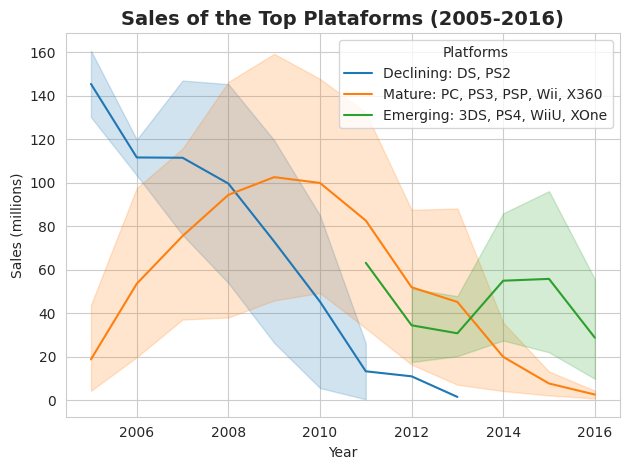

In [43]:


# Graph creation
axe = sns.lineplot(
    data=sales_by_platform,
    x='year_of_release',
    y='total_sales',
    hue='group',
    hue_order=['Declining','Mature','Emerging'],
    #palette=['orange','bluelight','green']
)

# Get the platforms by group
platforms_by_group = sales_by_platform.groupby('group')['platform'].unique()

# Change legend labels
legend_labels = [
    f"Declining: {', '.join(platforms_by_group['Declining'])}",
    f"Mature: {', '.join(platforms_by_group['Mature'])}",
    f"Emerging: {', '.join(platforms_by_group['Emerging'])}"
]

# Add Title and axes labels
plt.title(f'Sales of the Top Plataforms ({year}-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Sales (millions)')

# Change title
leg = axe.legend(title='Platforms')

# Replace labels
for txt, new_label in zip(leg.get_texts(), legend_labels):
    txt.set_text(new_label)

# Show grph
plt.tight_layout()
plt.show()



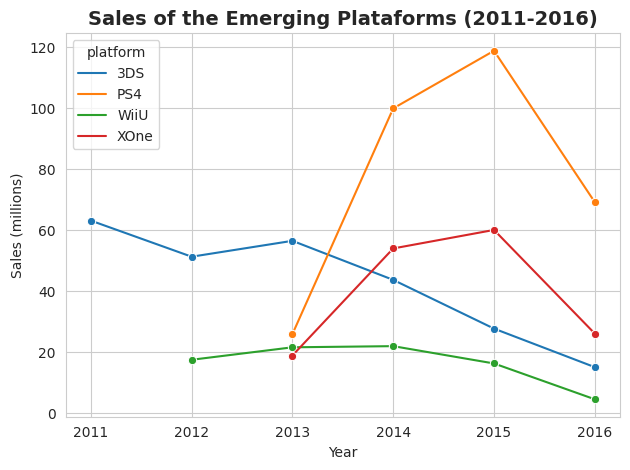

In [44]:
# Graph creation of the emerging platforms: sales by year
axe = sns.lineplot(
    data=sales_by_platform[sales_by_platform['group'] == 'Emerging'],
    x='year_of_release',
    y='total_sales',
    hue='platform',
    marker='o'
)

# Add Title and axes labels
plt.title(f'Sales of the Emerging Plataforms (2011-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Sales (millions)')


# Show grph
plt.tight_layout()
plt.show()



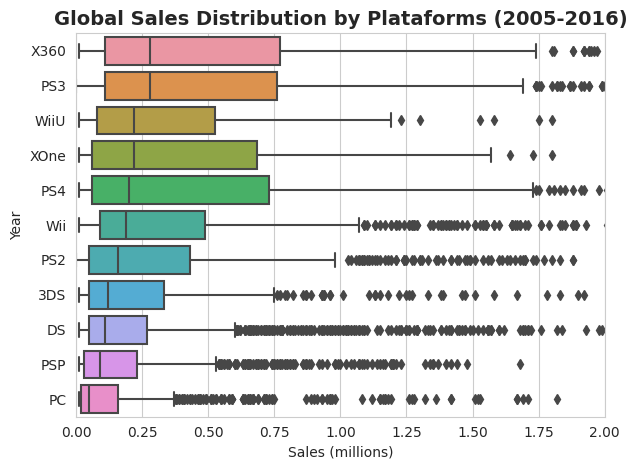

In [45]:
# List of platforms sorted by medians
platforms_list = recently_data.groupby('platform')['total_sales'].median().sort_values(ascending=False).index.to_list() 

# Box Plot of Sales by Platform
sns.boxplot(
    data=recently_data.sort_values(['platform','total_sales'], ascending=False),
    x='total_sales',
    y='platform',
    #whis=10,
    order=platforms_list
)

# Change the range in X axe
plt.xlim((0,2))

# Add Title and axes labels
plt.title(f'Global Sales Distribution by Plataforms ({year}-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Sales (millions)')
plt.ylabel('Year')

# Show grph
plt.tight_layout()
plt.show()


In [46]:
# Calculate stats of the platforms sales
stats_platform = recently_data.groupby('platform')['total_sales'].agg(['median','mean','std','var','count','sum']).sort_values('mean',ascending=False)
stats_platform

,median,mean,std,var,count,sum
platform,,,,,,
PS4,0.20,0.801378,1.609456,2.590350,392,314.14
X360,0.28,0.780227,1.632122,2.663823,1232,961.24
PS3,0.28,0.713663,1.403467,1.969721,1305,931.33
Wii,0.19,0.692986,3.165022,10.017362,1286,891.18
XOne,0.22,0.645020,1.036139,1.073584,247,159.32
WiiU,0.22,0.559116,1.058836,1.121133,147,82.19
3DS,0.12,0.503535,1.441271,2.077262,512,257.81
PS2,0.16,0.400432,0.707855,0.501059,1065,426.46
DS,0.11,0.374409,1.426706,2.035490,2098,785.51


<div class="alert alert-block alert-success">
<b>Reviewer's comment — Iteration 1</b> <a class="tocSkip"></a>

✅ **Platform lifecycle and significant period analysis — exceptional:**

- Frequency of platform appearances/disappearances (Cells 55). ✅
- Declining / Mature / Emerging classification with dynamic legend. ✅
- Boxplot with `xlim(0, 2)` — perfectly readable. ✅
- Statistics table (median, mean, std, var, count, sum). ✅
- The comparison of PS4 vs XOne with the same titles (Cells 79) is methodologically correct and well argued. ✅

</div>

## 3.6. Scores and Sales

- Analyze the relationship between game **ratings and sales** to determine whether higher-rated games tend to achieve better commercial performance.
- The **Play Sation 4** was chosen as the emerging platform for this analysis due to its strong sales performance.

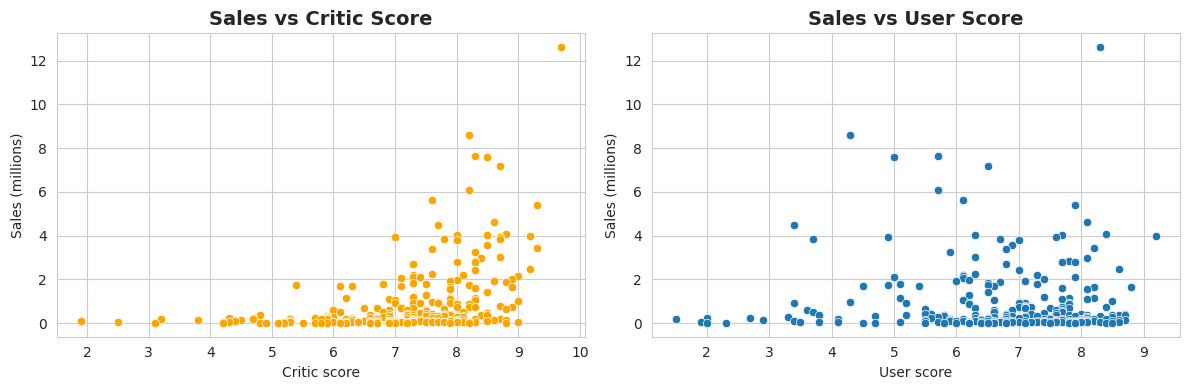

In [47]:
# Correlation of sales and scores in Xbox 360 platform
ps4_data = recently_data[recently_data['platform'] == 'PS4'].dropna(subset=['critic_score_10','user_score'])

# fig and axes creation
fig, axes = plt.subplots(1,2, figsize=(12,4))

# Scatter graph 
sns.scatterplot(
    data=ps4_data,
    x='critic_score_10',
    y='total_sales',
    color='orange',
    ax=axes[0]
)

# Scatter graph 
sns.scatterplot(
    data=ps4_data,
    x='user_score',
    y='total_sales',
    ax=axes[1]
)


axes[0].set_title('Sales vs Critic Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Critic score')
axes[0].set_ylabel('Sales (millions)')

axes[1].set_title('Sales vs User Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('User score')
axes[1].set_ylabel('Sales (millions)')

# Show graph
plt.tight_layout()
plt.show()

The scatter plots comparing sales and review scores reveal a very weak positive relationship. Although the trend is not strong, higher critic scores are generally associated with increased sales.

In [48]:
# Pearson correlation coefficient of sales and scores in Xbox 360 platform
ps4_data[['critic_score','user_score','mean_score','total_sales']].corr()

,critic_score,user_score,mean_score,total_sales
critic_score,1.000000,0.557654,0.863295,0.405895
user_score,0.557654,1.000000,0.900358,-0.033625
mean_score,0.863295,0.900358,1.000000,0.192338
total_sales,0.405895,-0.033625,0.192338,1.000000


<div class="alert alert-block alert-danger">
<b>Reviewer's comment — Iteration 1</b> <a class="tocSkip"></a>

❌ **Cell 69 — Correlation performed on Wii, inconsistent with Cell 68**

Cell 68 states: *"The Xbox 360 was chosen as the platform for this analysis."* But the code in Cell 69 filters:

```python
# Cell 69 (inconsistent):
x360_data = recently_data[... (recently_data['platform'] == 'Wii')]
```

The variable is named `x360_data` but filters Wii. This inconsistency between the markdown comment and the code means that the correlation analysis and the summary in Cell 85 (which reports r = 0.38 for critics) correspond to Wii, not Xbox 360.

More importantly, the rubric asks to analyze a **popular platform from the relevant period** that is promising for 2017. Both Wii and X360 are in the "Declining" group in your own classification (Cell 62).


Also, once `fillna(-1)` is corrected (see red comment above), the filter should be `dropna()` instead of `!= -1`.

</div>

## 3.7. Game Sales by Platform

Compare the sales performance of a game across different platforms to identify potential differences in market reach and commercial success.

In [49]:
# Finding the top-selling games
number_games = 10

top_games = recently_data.groupby('name')['total_sales'].sum().sort_values(ascending=False).reset_index()
top_games_list = top_games['name'].to_list()[:number_games]
top_games.head()


,name,total_sales
0,WII SPORTS,82.54
1,GRAND THEFT AUTO V,56.58
2,MARIO KART WII,35.52
3,WII SPORTS RESORT,32.77
4,CALL OF DUTY: MODERN WARFARE 3,30.60


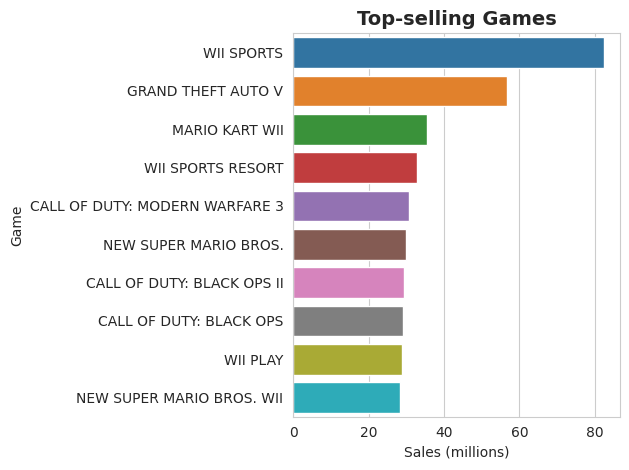

In [50]:

# Top-selling games
sns.barplot(
    data=top_games.head(number_games),
    x='total_sales',
    y='name',
)


# Set the title and axis labels
plt.title('Top-selling Games', fontsize=14, fontweight='bold')
plt.ylabel('Game')
plt.xlabel('Sales (millions)')

# Show graph
plt.tight_layout()
plt.show()



In [51]:
# Remove irrelevant columns and filterd the top game sales
sales_by_game = recently_data[recently_data['name'].isin(top_games_list)][['name','platform','total_sales','na_sales','eu_sales','jp_sales','other_sales']]
sales_by_game.head()

,name,platform,total_sales,na_sales,eu_sales,jp_sales,other_sales
0,WII SPORTS,Wii,82.54,41.36,28.96,3.77,8.45
2,MARIO KART WII,Wii,35.52,15.68,12.76,3.79,3.29
3,WII SPORTS RESORT,Wii,32.77,15.61,10.93,3.28,2.95
6,NEW SUPER MARIO BROS.,DS,29.80,11.28,9.14,6.50,2.88
7,WII PLAY,Wii,28.91,13.96,9.18,2.93,2.84


In [52]:
# Get the colors from the plots
colors = sns.color_palette()

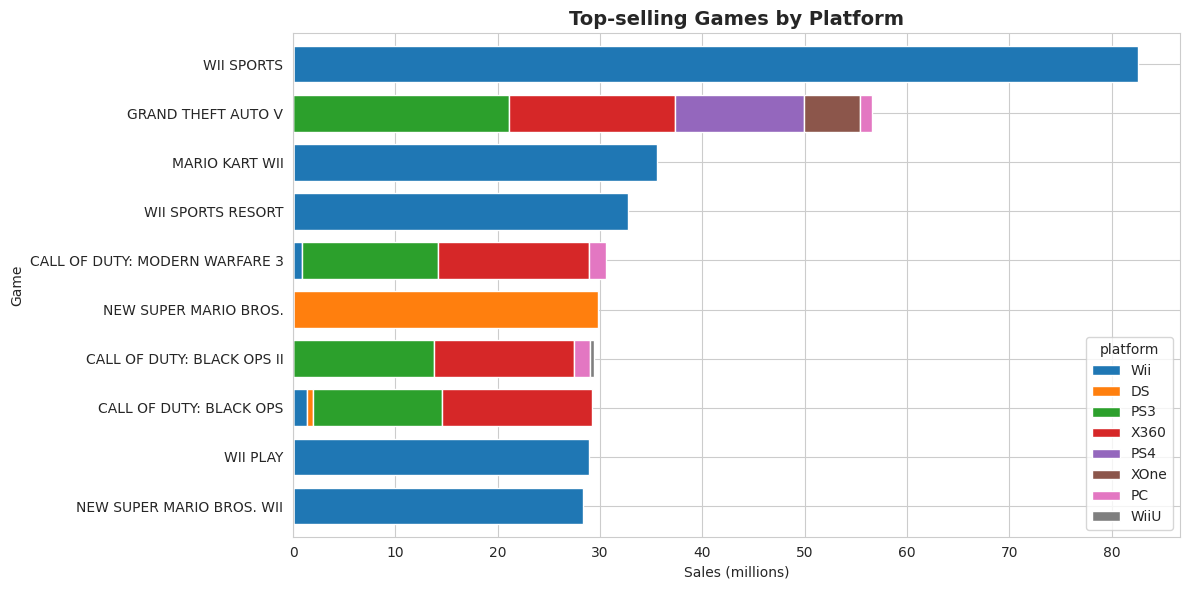

In [53]:
# Top-selling Games by Platform
# Create pivot table
sales_pivot = sales_by_game.pivot_table(index='name', columns='platform', values='total_sales', aggfunc='sum').fillna(0)

# Sort by total sales
sales_pivot = sales_pivot.loc[sales_pivot.sum(axis=1).sort_values().index]

# The desire columns order of the platforms
sales_pivot = sales_pivot[['Wii','DS','PS3','X360','PS4','XOne','PC','WiiU']]

# Bar plot
ax = sales_pivot.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.75,
)

# Add title and axes labels
plt.title('Top-selling Games by Platform', fontsize=14, fontweight='bold')
plt.xlabel('Sales (millions)')
plt.ylabel('Game')

# Show graph
plt.tight_layout()
plt.show()


The `DS` and `Wii` platforms will be **removed** from the analysis because mostly of their profit games are not available on other platforms, limiting their usefulness for cross-platform sales comparisons.

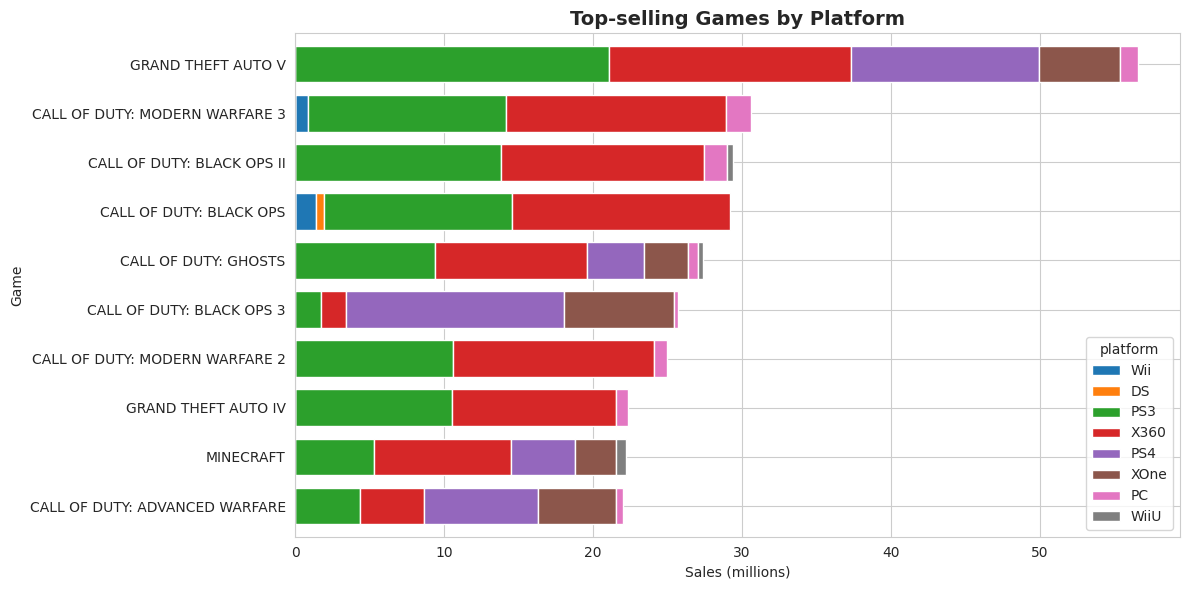

In [54]:
# Filtered games of platforms that no are Wii or DS
top_games_list = recently_data[~recently_data['platform'].isin(['Wii','DS'])].groupby('name')['total_sales'].sum().sort_values(ascending=False).reset_index()['name'].to_list()[:number_games]
sales_by_game = recently_data[recently_data['name'].isin(top_games_list)][['name','platform','total_sales','na_sales','eu_sales','jp_sales','other_sales']] # Filtered games

# Sales pivot table by game and platform
sales_pivot = sales_by_game.pivot_table(index='name', columns='platform', values='total_sales', aggfunc='sum').fillna(0)

# Sort by total sales
sales_pivot = sales_pivot.loc[sales_pivot.sum(axis=1).sort_values().index]

# The desire columns order of the platforms
sales_pivot = sales_pivot[['Wii','DS','PS3','X360','PS4','XOne','PC','WiiU']]

# Bar plot
ax = sales_pivot.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.75,
)

# Add title and axes labels
plt.title('Top-selling Games by Platform', fontsize=14, fontweight='bold')
plt.xlabel('Sales (millions)')
plt.ylabel('Game')

# Show graph
plt.tight_layout()
plt.show()

* **Nintendo's** exclusive titles generated the **highest sales** figures in the dataset.
* The most successful multiplatform games rely on combined sales across several platforms.
* **PS3 and Xbox 360** were the dominant platforms for multiplatform games during the analyzed period.
* Newer platforms, such as **PS4 and Xbox One**, gained relevance in recent game releases.
* **PC sales** are generally **lower** than console sales for top-selling games.
* **Platform availability** appears to be an important factor in **maximizing** a game's commercial performance.

## 3.8. Game Genres

Analyze whether a game's genre influences its sales performance.

In [55]:
# Genre group
genre_group = recently_data.groupby('genre').agg({'name':'nunique', 'total_sales':'sum'}).sort_values('total_sales', ascending=False).reset_index()
genre_group.columns = ['genre','games','total_sales'] # Columns names change

# New column with average sales per game
genre_group['average'] = genre_group['total_sales'] / genre_group['games']
genre_group

,genre,games,total_sales,average
0,Action,1272,1147.57,0.902178
1,Sports,692,826.89,1.194928
2,Shooter,440,737.51,1.676159
3,Misc,964,594.80,0.617012
4,Role-Playing,796,529.46,0.665151
5,Racing,318,341.08,1.072579
6,Platform,221,288.06,1.303439
7,Simulation,527,266.43,0.505560
8,Fighting,288,201.42,0.699375
9,Adventure,776,140.31,0.180812


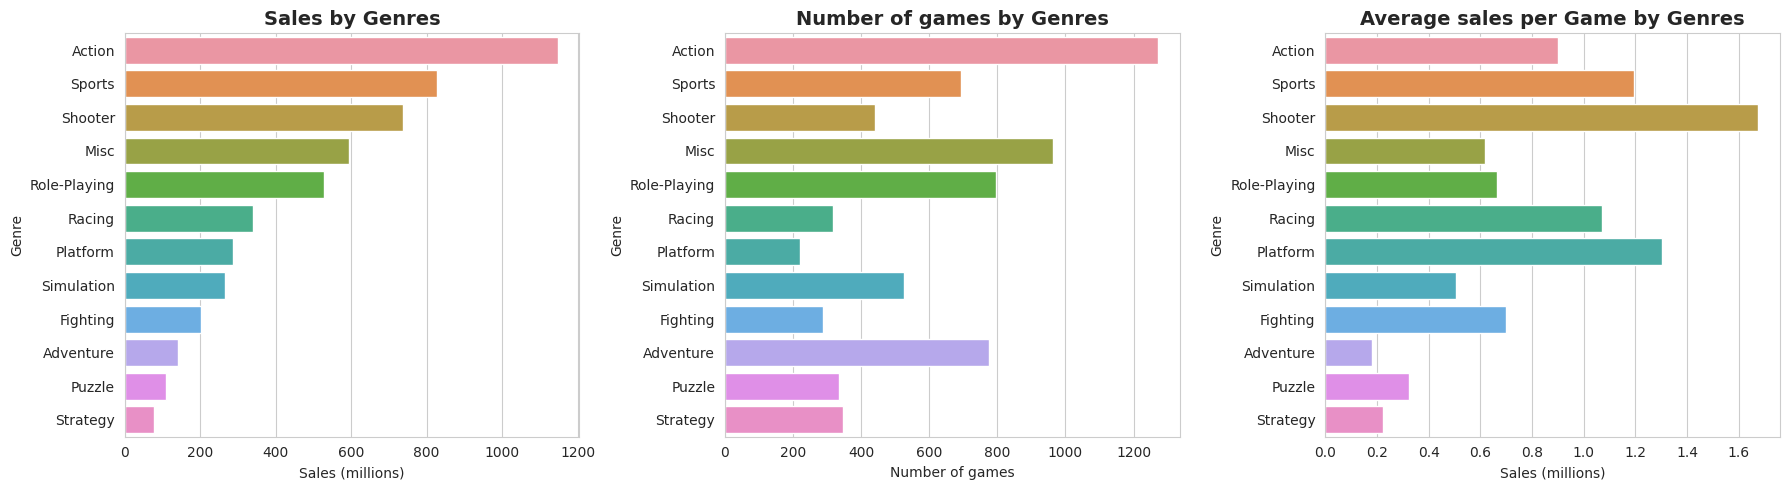

In [56]:
# Game genres distribution
fig, axes = plt.subplots(1,3, figsize=(18,5))

# Game genres distribution by sales
ax = sns.barplot(
    data=genre_group,
    x='total_sales',
    y='genre',
    ax=axes[0]
)

# Game genres distribution by number of games
ax = sns.barplot(
    data=genre_group,
    x='games',
    y='genre',
    ax=axes[1]
)

# Game genres distribution by average sales per game
ax = sns.barplot(
    data=genre_group,
    x='average',
    y='genre',
    ax=axes[2]
)

# Set titles and axes labels
axes[0].set_title('Sales by Genres', fontsize=14, fontweight='bold')
axes[1].set_title('Number of games by Genres', fontsize=14, fontweight='bold')
axes[2].set_title('Average sales per Game by Genres', fontsize=14, fontweight='bold')

axes[0].set_xlabel('Sales (millions)')
axes[1].set_xlabel('Number of games')
axes[2].set_xlabel('Sales (millions)')

axes[0].set_ylabel('Genre')
axes[1].set_ylabel('Genre')
axes[2].set_ylabel('Genre')

# Show graph
plt.tight_layout()
plt.show()


* The **top three** genres in terms of total sales are **Action, Sports, and Shooter.**
* **Shooter** is the highest-performing genre on a per-game basis, generating an average of more than **1.6 million** units sold per title.
* **Adventure** is the genre with the **lowest** average sales per game, with fewer than **0.2 million** units sold per title on average.
* **Strategy** is the **least** profitable genre overall.

## 3.9. Data Analysis Summary

**Market Evolution and Platform Lifecycle**

- Games were grouped into three eras: *Retro* (`1980-1994`), *Classic* (`1995-2005`), and *Modern* (`2006-2016`).
- Modern games account for **63%** of all titles in the dataset, followed by Classic games (**34%**) and Retro games (**3%**).
- The top-selling platforms are **PS2, X360, PS3, Wii, DS, and PS1**.
- Although these platforms generated the highest historical sales, most recorded little to no activity by **2016**.
- The average lifespan of the six best-selling platforms is approximately **10 years**, compared to **6.3 years** for less successful platforms.
- **PC** has the longest lifespan among active platforms, although it ranks only tenth in total sales with approximately **$259 million**.
- New platforms emerge every **1.1 years** on average, while an existing platform ceases to receive new game releases every **1.2 years**.
- To build a model for **2017**, the analysis focuses on the **2005-2016** period, corresponding to the typical lifecycle of major platforms.

**Platform Performance**
- During the last decade, the leading platforms were **X360, PS3, Wii, and DS**.
- Declining platforms include **DS, PS2, PS3, PSP, Wii, and X360**.
- Emerging platforms include **3DS, PS4, Wii U, and Xbox One**.
- **PS4** and **Xbox One** appear to be promising platforms, as their sales increased steadily after launch. The decline observed in 2016 is likely due to incomplete yearly data.

**Sales Distribution**
- Sales distributions across platforms are **right-skewed**, with a large number of outliers inflating the mean.
- **Xbox 360** and **PS3** provide the highest median sales performance, with a typical game generating around **\\$280,000** in sales.
- The substantial gap between the mean and median across all platforms indicates the presence of numerous blockbuster titles.
- On Xbox 360, the mean exceeds the median by approximately **\\$500,000**.
- **Wii** exhibits the greatest variability in sales per game, with an average of **\\$693,000** and a standard deviation of approximately **\\$3.17 million**.
- **PS4** has the highest average sales per game, exceeding **\\$800,000 per title**.


**Review Scores and Sales for PlayStation 4 platform**
- The Pearson correlation coefficient between sales and **critic scores** is **0.41**, indicating a **moderate positive relationship**. Games that receive higher critic ratings tend to achieve better sales, suggesting that professional reviews may have some influence on consumer purchasing decisions.
- The Pearson correlation coefficient between sales and **user scores** is **-0.03**, indicating **virtually no relationship** between user ratings and sales. This suggests that user reviews are not a reliable predictor of commercial success on the PS4 platform.


**Top-Selling Games**
- **Nintendo exclusives** dominate the list of best-selling games, with *Wii Sports* standing out as the highest-selling title.
- Multiplatform releases such as *Grand Theft Auto V* and *Call of Duty* achieve high sales by combining performance across several platforms.
- **PS3** and **Xbox 360** contributed the largest share of sales for most successful multiplatform titles.
- The influence of **PS4** and **Xbox One** becomes increasingly evident in more recent releases.
- Both **platform exclusivity** and **multiplatform availability** proved effective strategies for achieving strong commercial performance.

**Genre Analysis**
- The top-selling genres are **Action**, **Sports**, and **Shooter**.
- **Shooter** is the most successful genre on a per-game basis, averaging more than **1.6 million units sold per title**.
- **Adventure** records the lowest average sales per game, with fewer than **0.2 million units sold per title**.
- **Strategy** is the least profitable genre overall.

# 4. Region User Profile 



## 4.1. Platforms by region

In [57]:
# Main platforms by region
region_sales = recently_data.groupby('platform')['na_sales','eu_sales','jp_sales','other_sales'].sum().sort_values(['na_sales','eu_sales','jp_sales','other_sales'], ascending=False).reset_index()
region_sales

# Long format of regions sales
region_sales = pd.melt(
    region_sales,
    id_vars='platform',
    value_vars=['na_sales','eu_sales','jp_sales','other_sales'],
    var_name='region',
    value_name='sales'
)
region_sales

,platform,region,sales
0,X360,na_sales,595.74
1,Wii,na_sales,486.87
2,PS3,na_sales,390.13
3,DS,na_sales,371.98
4,PS2,na_sales,200.49
5,PS4,na_sales,108.74
6,PSP,na_sales,105.02
7,XOne,na_sales,93.12
8,3DS,na_sales,82.65
9,PC,na_sales,45.84


In [58]:
# Return the top N rows within each category based on a ranking column
def get_top_records(df, category_col, value_col, top_n=5):
    """
    Return the top N rows for each category based on a specified value column.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.
    category_col : str
        Column containing the categories used for grouping.
    value_col : str
        Column containing the values used for ranking.
    top_n : int, default=5
        Number of rows to return for each category.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the top N rows within each category,
        sorted by the highest values in `value_col`.

    Examples
    --------
    >>> get_top_records(df, 'region', 'sales', top_n=5)
    """

    top_df = pd.DataFrame()

    for category in df[category_col].unique():
        top_df = pd.concat([top_df,df[df[category_col] == category].sort_values(value_col, ascending=False).head(top_n)])

    top_df.reset_index(drop=True, inplace=True)

    return top_df

In [59]:
# Get the Top 5 platforms of each region
region_platforms = get_top_records(region_sales, 'region', 'sales')
region_platforms

,platform,region,sales
0,X360,na_sales,595.74
1,Wii,na_sales,486.87
2,PS3,na_sales,390.13
3,DS,na_sales,371.98
4,PS2,na_sales,200.49
5,PS3,eu_sales,327.20
6,X360,eu_sales,268.32
7,Wii,eu_sales,258.32
8,DS,eu_sales,184.48
9,PS4,eu_sales,141.09


In [60]:
# Assign a color with a platform
platforms = region_platforms['platform'].unique()
colors = sns.color_palette().as_hex()[:len(platforms)]
platform_color = dict(zip(platforms, colors))

platform_color

{'X360': '#1f77b4',
 'Wii': '#ff7f0e',
 'PS3': '#2ca02c',
 'DS': '#d62728',
 'PS2': '#9467bd',
 'PS4': '#8c564b',
 '3DS': '#e377c2',
 'PSP': '#7f7f7f'}

In [61]:
# Dictionary of regions
regions_dic = {
    'na_sales': 'North America',
    'eu_sales': 'Europe',
    'jp_sales': 'Japan',
    'other_sales': 'Others',
}

# Replace in region_platforms
region_platforms['region'].replace(regions_dic, inplace=True)
region_platforms.head()

,platform,region,sales
0,X360,North America,595.74
1,Wii,North America,486.87
2,PS3,North America,390.13
3,DS,North America,371.98
4,PS2,North America,200.49


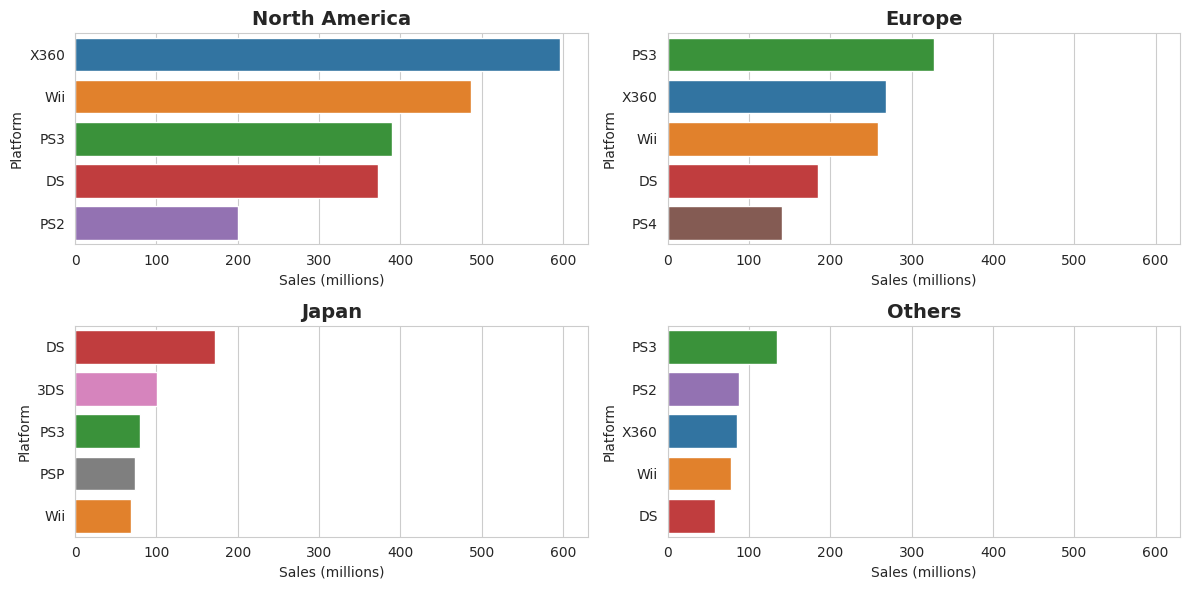

In [62]:
# The five platforms of each region
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

regions = region_platforms['region'].unique()

for ax, region in zip(axes.flat, regions):

    temp = (region_platforms.query('region == @region').sort_values('sales', ascending=False))

    sns.barplot(
        data=temp,
        x='sales',
        y='platform',
        ax=ax,
        palette=platform_color
    )

    ax.set_title(region, fontsize=14, fontweight='bold')
    ax.set_xlabel('Sales (millions)')
    ax.set_ylabel('Platform')
    ax.set_xlim(0,630)

plt.tight_layout()
plt.show()


* **PlayStation 3, Wii, and DS** are the only platforms that appear among the top-selling platforms in **all regions.**
* The **Xbox 360** does **not** rank among the top five platforms **in Japan.** However, it is the **best-selling** platform in **North America** and the second best-selling platform in Europe.
* Although **PlayStation 4** is an emerging platform, it already ranks among the **top five** platforms **in Europe** in terms of sales.
* In the **Others** regions, **Nintendo** platforms **dominate** the market, with Xbox 360 being the only non-Nintendo platform among the top performers.


In [63]:
# Total sales by region
regions_sales = region_platforms.groupby('region')['sales'].sum().sort_values(ascending=False).reset_index()
regions_sales['percent'] = regions_sales['sales'] / regions_sales['sales'].sum()
regions_sales

,region,sales,percent
0,North America,2045.21,0.491535
1,Europe,1179.41,0.283453
2,Japan,493.53,0.118612
3,Others,442.71,0.106399


* **North America** has the `49%` of the total sales: `2 billions` dolars.
* **Europe** with the `28%`: `1.18 billions` dolars.

In [64]:
# Marker share
total_sales_region = {}
for region in region_platforms['region'].unique():
    total_sales_region[region] = region_platforms[region_platforms['region'] == region]['sales'].sum()

region_platforms['total_sales'] = region_platforms['region'].replace(total_sales_region) # Column with the total sales of the region

region_platforms['market_share'] = (region_platforms['sales'] / region_platforms['total_sales'])*100 # Column with the market share of the region

# Convert to pivot table
region_platforms = region_platforms.pivot_table(index='region', columns='platform', values='market_share', aggfunc='sum').fillna(0).reset_index()
region_platforms

platform,region,3DS,DS,PS2,PS3,PS4,PSP,Wii,X360
0,Europe,0.000000,15.641719,0.000000,27.742685,11.962761,0.000000,21.902477,22.750358
1,Japan,20.387818,34.723320,0.000000,16.090207,0.000000,14.963629,13.835025,0.000000
2,North America,0.000000,18.187863,9.802905,19.075303,0.000000,0.000000,23.805379,29.128549
3,Others,0.000000,13.028845,19.843690,30.401391,0.000000,0.000000,17.553252,19.172822


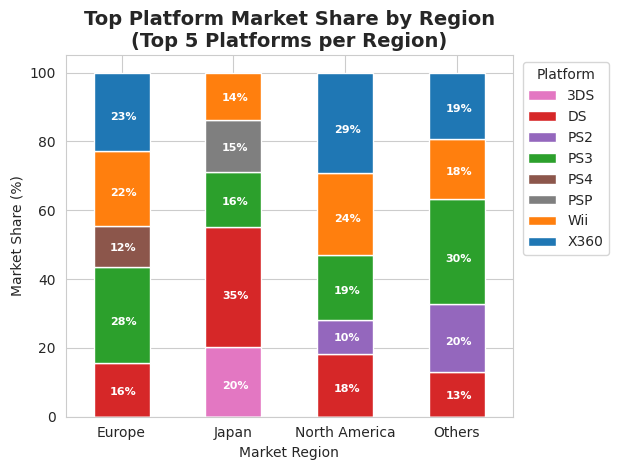

In [65]:
# Top Platform Market Share by Region plot
ax = region_platforms.plot(
    kind='bar',
    x='region',
    stacked=True,
    color=platform_color,
    rot=0
)

# Add Title and axe labels
plt.title('Top Platform Market Share by Region\n(Top 5 Platforms per Region)', fontsize=14, fontweight='bold')
plt.xlabel('Market Region')
plt.ylabel('Market Share (%)')

# Move the legend
ax.legend(title='Platform', loc=1, bbox_to_anchor=(1.23,1))

# Add value labels
for patch in ax.patches:
    position, width, height = patch.xy, patch.get_width() , patch.get_height()
    if height != 0:
        ax.text(x=position[0]+width/3.4, y=position[1]+height/2.5, s=f'{height:.0f}%', fontsize=8, fontweight='bold', color='white')

# Show graph
plt.tight_layout()
plt.show()

Note: Percentages are based on the top five platforms in each region.

* **North America** is dominated by Xbox 360 (29%), followed by Wii (24%) and PS3 (19%). This indicates a strong preference for **Microsoft and Nintendo** platforms in the region.
* **Europe** shows a more **balanced distribution.** PS3 (28%) holds the largest market share, closely followed by Xbox 360 (23%) and Wii (22%), suggesting stronger competition among the leading platforms.
* **Japan** has a markedly different market profile. Handheld **Nintendo** consoles dominate the market, with DS (35%) and 3DS (20%) accounting for more than half of the market share among the top platforms. In contrast, Xbox 360 is absent from the top five.
* **Other regions** are led by PS3 (30%), while PS2 (20%), Xbox 360 (19%), and Wii (18%) hold similar shares. This region exhibits a more **diversified** distribution across platforms.

## 4.2. Genres by region

In [66]:
# Top 5 genres by region
region_genres = recently_data.groupby('genre')[['na_sales','eu_sales','jp_sales','other_sales','total_sales']].sum().reset_index()
region_genres

,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales
0,Action,549.96,359.32,100.38,137.91,1147.57
1,Adventure,61.87,38.03,27.81,12.60,140.31
2,Fighting,100.89,45.80,30.51,24.22,201.42
3,Misc,299.69,162.40,69.05,63.66,594.80
4,Platform,139.86,82.76,36.12,29.32,288.06
5,Puzzle,48.22,33.55,18.43,8.76,108.96
6,Racing,154.73,124.88,17.41,44.06,341.08
7,Role-Playing,205.51,112.51,168.86,42.58,529.46
8,Shooter,387.48,242.21,20.22,87.60,737.51
9,Simulation,124.65,85.32,32.21,24.25,266.43


In [67]:
# Long table
region_genres_long = region_genres.melt(
    id_vars='genre',
    value_vars=['na_sales','eu_sales','jp_sales','other_sales','total_sales'],
    var_name='region',
    value_name='sales'
)

# Change region values
region_genres_long.replace(regions_dic, inplace=True)
region_genres_long

,genre,region,sales
0,Action,North America,549.96
1,Adventure,North America,61.87
2,Fighting,North America,100.89
3,Misc,North America,299.69
4,Platform,North America,139.86
5,Puzzle,North America,48.22
6,Racing,North America,154.73
7,Role-Playing,North America,205.51
8,Shooter,North America,387.48
9,Simulation,North America,124.65


In [68]:
# Get the top 5 genres by region
region_genres_long = get_top_records(region_genres_long, 'region', 'sales')
region_genres_long

,genre,region,sales
0,Action,North America,549.96
1,Sports,North America,415.51
2,Shooter,North America,387.48
3,Misc,North America,299.69
4,Role-Playing,North America,205.51
5,Action,Europe,359.32
6,Sports,Europe,259.48
7,Shooter,Europe,242.21
8,Misc,Europe,162.40
9,Racing,Europe,124.88


In [69]:
# Assign a color with a genre
genres = region_genres_long['genre'].unique()
colors = sns.color_palette().as_hex()[:len(genres)]
genre_color = dict(zip(genres, colors))

genre_color

{'Action': '#1f77b4',
 'Sports': '#ff7f0e',
 'Shooter': '#2ca02c',
 'Misc': '#d62728',
 'Role-Playing': '#9467bd',
 'Racing': '#8c564b',
 'Platform': '#e377c2'}

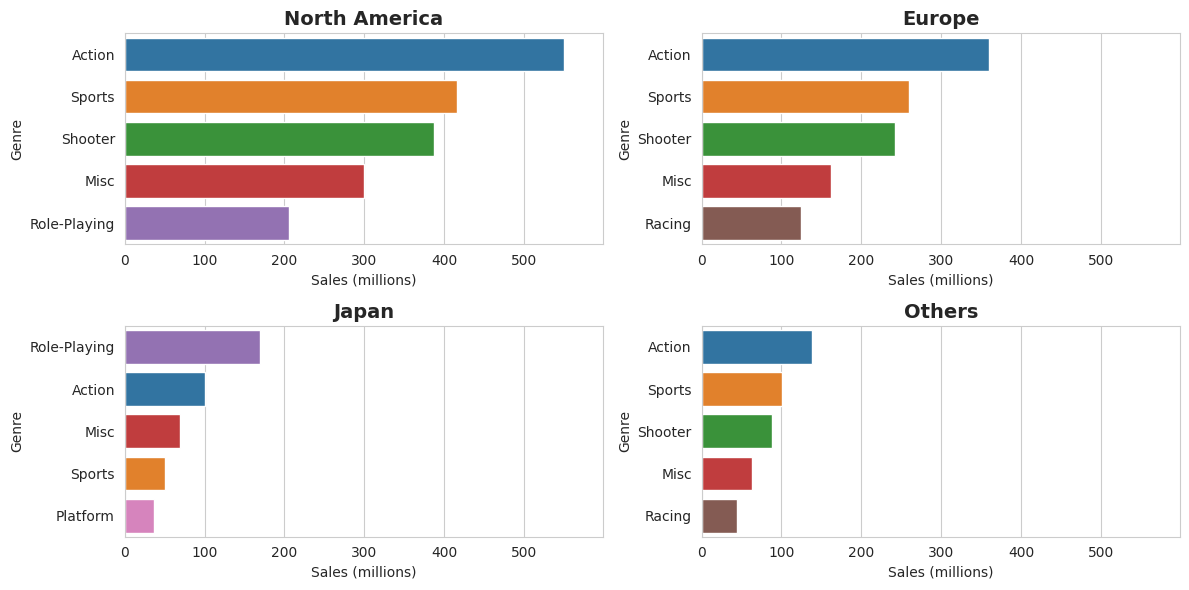

In [70]:
# The five platforms of each region
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

regions = region_genres_long['region'].unique()

for ax, region in zip(axes.flat, regions):

    temp = (region_genres_long.query('region == @region').sort_values('sales', ascending=False))

    sns.barplot(
        data=temp,
        x='sales',
        y='genre',
        ax=ax,
        palette=genre_color
    )

    ax.set_title(region, fontsize=14, fontweight='bold')
    ax.set_xlabel('Sales (millions)')
    ax.set_ylabel('Genre')
    ax.set_xlim(0,599)

plt.tight_layout()
plt.show()

* **Japan** exhibits a markedly different gaming preference compared to other regions, with **Role-Playing** games representing the best-selling genre by a wide margin.
* **Shooter** games, which rank among the top-selling genres in **North America and Europe**, have a relatively low market presence in Japan.
* **North America, Europe, and Other Regions** display very similar genre preferences, with **Action, Sports, Shooter, and Miscellaneous** consistently ranking among the top-selling categories.
* **Action games** are the leading genre in **North America, Europe, and Other Regions**, highlighting their broad international appeal.

## 4.3. ESRB by Region

Determine whether ESRB ratings influence sales across individual regions.

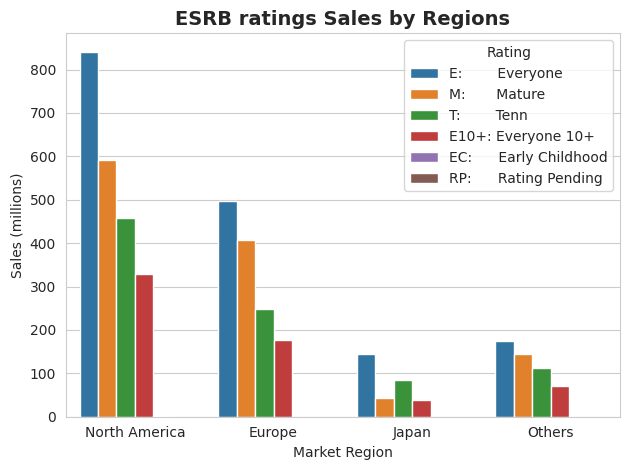

In [71]:
# Group by rating
rating_sales = (recently_data.groupby('rating')
    [['na_sales','eu_sales','jp_sales','other_sales','total_sales']]
    .sum()
    .sort_values('total_sales', ascending=False) 
    .reset_index()
    .melt( # Long table
        id_vars='rating', 
        value_vars=['na_sales','eu_sales','jp_sales','other_sales'],
        var_name='region',
        value_name='sales'
    )
)

# Replace region names
rating_sales['region'].replace(regions_dic, inplace=True)

# Replace rating names
rating_dic = {
    'EC':'EC:      Early Childhood',
    'E':'E:        Everyone',
    'E10+':'E10+: Everyone 10+',
    'T':'T:        Tenn',
    'M':'M:       Mature',
    'AO':'AO:   Adults Only',
    'RP': 'RP:      Rating Pending'
}
rating_sales['rating'].replace(rating_dic, inplace=True)

# Barplot
ax = sns.barplot(
    data=rating_sales[rating_sales['rating'] != 'NO_RATING'], # Filter data with rating
    x='region',
    y='sales',
    hue='rating'
)

# Add Title and axe labels
plt.title('ESRB ratings Sales by Regions', fontsize=14, fontweight='bold')
plt.xlabel('Market Region')
plt.ylabel('Sales (millions)')

# Change title in legend
plt.legend(title='Rating')

# Show graph
plt.tight_layout()
plt.show()

* The ESRB ratings with the **highest sales** are **E** (Everyone), **M** (Mature 17+), **T** (Teen 13+), and **E10+** (Everyone 10+).
* Most regions share the same ranking of ESRB categories, with E-rated games generating the highest sales, followed by M, T, and E10+ titles.
* **Japan** is the only exception to this pattern. While **E-rated** games remain the top-selling category, **T-rated** games rank second, surpassing **M-rated** games, which fall to third place.
* This suggests that gaming preferences in Japan differ from those in Western markets, where mature-rated games tend to have stronger commercial performance.

## 4.4. Region User Profile Summary

* Platform preferences vary considerably across regions. **North America** favors Xbox 360, **Europe** is more evenly distributed among major platforms, **Japan** is strongly dominated by Nintendo handheld consoles, and **Other regions** show a balanced mix of PlayStation, Nintendo, and Xbox platforms.
* Genre preferences vary significantly across regions. While **Western markets** share similar tastes and are dominated by **Action, Sports, and Shooter games**, **Japan** stands out as a unique market where **Role-Playing** games are the primary driver of sales. This suggests that regional cultural preferences play an important role in determining the commercial success of different game genres.
* ESRB ratings appear to influence sales across regions. **E-rated** games consistently generate the **highest sales**, indicating broad market appeal, while **M-rated** games perform particularly well in **Western markets**. **Japan** stands out as the only region where **T-rated** games outperform M-rated titles, reflecting distinct regional preferences and player demographics.

<div class="alert alert-block alert-success">
<b>Reviewer's comment — Iteration 1</b> <a class="tocSkip"></a>

✅ **Regional profile — one of the most complete and visual of the sprint:**

- `get_top_records()` reusable function with proper docstring. ✅
- Stacked market share chart with value labels per bar (Cell 98). ✅
- 2×2 panel charts for platforms, genres, and ESRB. ✅
- Well-differentiated conclusions for each region. ✅
- ESRB analysis correctly filtered with `!= 'NO_RATING'`. ✅

</div>

# 5. Hypotesis Testing

To evaluate potential differences in user ratings across platforms and genres, two independent hypothesis tests were conducted. An alpha level (`α`) of **0.05** was selected, meaning that a result is considered statistically significant when the *p-value* is less than 0.05.

## 5.1. Testing Method

An **independent two-sample t-test** was used to compare the means of the two groups in each hypothesis test. This method is appropriate because:

- The samples belong to independent groups.
- The objective is to compare average user ratings.
- The t-test determines whether any observed difference between the sample means is statistically significant or could be explained by random variation.

## 5.2. Decision Rule

- If the **p-value < 0.05**, reject the null hypothesis (**H₀**).
- If the **p-value ≥ 0.05**, fail to reject the null hypothesis (**H₀**).

This criterion provides a confidence level of **95%** when evaluating the statistical significance of the results.

## 5.3. Hypothesis 1: Xbox One vs. PC User Ratings

**Null Hypothesis (H₀):**
> The average user ratings for Xbox One and PC games are equal.

**Alternative Hypothesis (H₁):**
> The average user ratings for Xbox One and PC games are different.

In [72]:


# Xbox One data
xbox_one = recently_data[['name','platform','user_score']][recently_data['platform'] == 'XOne'].dropna().sort_values('user_score', ascending=False)['user_score']
display(xbox_one.head())



1498     9.2
13641    8.9
16137    8.8
9372     8.7
4885     8.6
Name: user_score, dtype: float64

In [73]:
# PC data
pc = recently_data[['name','platform','user_score']][recently_data['platform'] == 'PC'].dropna().sort_values('user_score', ascending=False)['user_score']
display(pc.head())

9140     9.3
2850     9.3
15288    9.2
12067    9.0
2114     8.9
Name: user_score, dtype: float64

In [74]:
# Means and standard desviation
print('Xbox One observations:', len(xbox_one))
print('PC observations:', len(pc))

print()

print('Xbox One mean:', xbox_one.mean())
print('PC mean:', pc.mean())

print()

print('Xbox One std:', xbox_one.std())
print('PC std:', pc.std())

Xbox One observations: 182
PC observations: 644

Xbox One mean: 6.521428571428572
PC mean: 6.884937888198757

Xbox One std: 1.380940564592144
PC std: 1.5157667464780522


In [75]:
# Set alpha
alpha = 0.05 # 5% significance level

In [76]:
# Test for equality of variances between the two groups
levene_result = st.levene(xbox_one, pc)

print(f'P_Value = {levene_result.pvalue:.4f}')

equal_var = levene_result.pvalue >= alpha  # True if variances are equal

if equal_var:
    print('There is no evidence that the variances are different')
else:
    print('The variances are significantly different')

P_Value = 0.2376
There is no evidence that the variances are different


In [77]:
# Student independant T test
result = st.ttest_ind(xbox_one, pc, equal_var=equal_var)

print(f'P_Value = {result.pvalue:.4f}')

if result.pvalue < alpha:
    print('Reject H0: The average user ratings for Xbox One and PC games are equal.')
else:
    print('Fail to reject H0: The average user ratings for Xbox One and PC games are equal.')

P_Value = 0.0037
Reject H0: The average user ratings for Xbox One and PC games are equal.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment — Iteration 1</b> <a class="tocSkip"></a>

⚠️ **Hypothesis 1 (Cell 122) — uses `equal_var=True` after Levene**

The Levene test in Cell 121 is an excellent addition — it checks for variance equality before the t-test. However, Cell 122 then uses `equal_var=True` regardless of the Levene result. The expected pattern when using Levene is to make `equal_var` dynamic:

```python
# Dynamic equal_var based on Levene result:
levene_result = st.levene(xbox_one, pc)
equal_var = levene_result.pvalue >= alpha  # True if variances are equal

result = st.ttest_ind(xbox_one, pc, equal_var=equal_var)
```

This way the test automatically adapts to the data. Note that H2 (Cell 129) already uses `equal_var=False` correctly ✅ — just H1 needs this adjustment.

Also note: once the `-1` imputation is corrected, the `user_score != -1` filter in Cells 117-118 should be replaced with `.dropna()`.

</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment — Iteration 2</b> <a class="tocSkip"></a>

✅ **Dynamic `equal_var` based on Levene — corrected and improved.** Cells 131-132 (H1) and 139-140 (H2) now compute:

```python
equal_var = levene_result.pvalue >= alpha
result = st.ttest_ind(..., equal_var=equal_var)
```

This is the most rigorous implementation of the Levene + t-test pattern: the test automatically adapts to the variance structure of the data. Both hypotheses are now methodologically complete and correct. ✅

</div>

**Reject H₀.** There is sufficient evidence to conclude that the average **user ratings** for **Xbox One** and **PC** games are significantly **different.**

## 5.4. Hypothesis 2: Action vs. Sports User Ratings

**Null Hypothesis (H₀):**
> The average user ratings for Action and Sports games are equal.

**Alternative Hypothesis (H₁):**
> The average user ratings for Action and Sports games are different.

In [78]:
# Action data
action = recently_data[recently_data['genre'] == 'Action']['user_score'].dropna().sort_values(ascending=False)
action.head()

10103    9.5
3207     9.3
3622     9.3
2202     9.1
3518     9.1
Name: user_score, dtype: float64

In [79]:
# Sport data
sports = recently_data[recently_data['genre'] == 'Sports']['user_score'].dropna().sort_values(ascending=False)
sports.head()

8140     9.2
3746     9.1
12067    9.0
10317    9.0
2739     9.0
Name: user_score, dtype: float64

In [80]:
# Means and standard desviation
print('Action observations:', len(action))
print('Sports observations:', len(sports))

print()

print('Action mean:', action.mean())
print('Sports mean:', sports.mean())

print()

print('Action std:', action.std())
print('Sports std:', sports.std())

Action observations: 1333
Sports observations: 697

Action mean: 6.90847711927982
Sports mean: 6.46571018651363

Action std: 1.357288800993881
Sports std: 1.6350113683115952


In [81]:
# Test for equality of variances between the two groups
levene_result = st.levene(action, sports)

print(f'P_Value = {levene_result.pvalue:.7f}')

equal_var = levene_result.pvalue >= alpha  # True if variances are equal

if equal_var:
    print('There is no evidence that the variances are different')
else:
    print('The variances are significantly different')

P_Value = 0.0000012
The variances are significantly different


In [82]:
# Student independant T test
result = st.ttest_ind(action, sports, equal_var=equal_var)

print(f'P_Value = {result.pvalue:.10f}')

if result.pvalue < alpha:
    print('Reject H0: The average user ratings for Action and Sports genres are equal.')
else:
    print('Fail to reject H0: The average user ratings for Action and Sports genres are equal.')


P_Value = 0.0000000012
Reject H0: The average user ratings for Action and Sports genres are equal.


<div class="alert alert-block alert-success">
<b>Reviewer's comment — Iteration 2</b> <a class="tocSkip"></a>

✅ **Dynamic `equal_var` based on Levene — corrected and improved.** Cells 131-132 (H1) and 139-140 (H2) now compute:

```python
equal_var = levene_result.pvalue >= alpha
result = st.ttest_ind(..., equal_var=equal_var)
```

This is the most rigorous implementation of the Levene + t-test pattern: the test automatically adapts to the variance structure of the data. Both hypotheses are now methodologically complete and correct. ✅

</div>

**Reject H₀.** There is sufficient evidence to conclude that the average **user ratings** for **Action** and **Sports** genres are significantly **different.**

# 6. Conclusions

The objective of this project was to identify the factors that contribute to a video game's commercial success and provide insights that can support marketing decisions for 2017. Based on the analysis, the following conclusions were obtained:

- The video game industry experienced significant growth during the **Modern Era (2006-2016)**, which accounts for the majority of titles in the dataset. This period also represents the most relevant timeframe for predicting future market trends.

- Successful gaming platforms tend to remain relevant for approximately **10 years**, whereas less profitable platforms have a considerably shorter lifespan. As a result, platform age and lifecycle should be considered when forecasting future sales.

- Several historically successful platforms, including **PS2, PS3, Wii, DS, PSP, and Xbox 360**, were already in decline by 2016. In contrast, **PS4** and **Xbox One** were still expanding their market presence, making them the most promising platforms for future releases and marketing investments.

- Sales distributions are highly skewed by blockbuster titles. A small number of games generate a disproportionate share of total revenue, creating large differences between average and median sales across all platforms.

- **Critic reviews** appear to have a moderate **influence** on **sales** performance for **PS4** games, whereas **user** reviews show almost **no predictive** value. While higher critic scores are generally associated with stronger sales, user ratings do not exhibit a meaningful relationship with commercial success. This suggests that professional reviews may be more influential than community ratings in shaping purchasing decisions on the PS4 platform.

- The most commercially successful games follow two distinct strategies:
  - Developing strong platform exclusives, as demonstrated by Nintendo titles such as *Wii Sports*.
  - Releasing games across multiple platforms, as seen with franchises such as *Grand Theft Auto* and *Call of Duty*.

- **Genre selection** is an important success factor. While **Action**, **Sports**, and **Shooter** generate the highest overall sales, **Shooter** is the most profitable genre on a per-title basis. Conversely, **Adventure** and **Strategy** genres generally produce weaker financial results.

- Consumer preferences differ substantially by region. North America and Europe show similar tastes, favoring Action, Sports, and Shooter games, whereas Japan exhibits unique preferences driven primarily by Role-Playing games and Nintendo platforms.

- Regional differences are also reflected in platform popularity and ESRB ratings. While mature-rated games achieve strong sales in Western markets, Japanese consumers demonstrate a stronger preference for Teen-rated titles.

- Statistical hypothesis testing confirmed that:
  - Average user ratings for **Xbox One** and **PC** games are significantly different.
  - Average user ratings for **Action** and **Sports** games are significantly different.

## Final Recommendation

For a marketing strategy focused on **2017**, the strongest opportunities appear to be games released on **PS4** and **Xbox One**, particularly within the **Action**, **Sports**, and **Shooter** genres. Marketing efforts should also be adapted to regional preferences, as consumer behavior differs considerably between Western markets and Japan. Additionally, obtaining favorable critic reviews may contribute positively to a game's commercial performance, making review management and media exposure important components of a successful launch strategy.